# DistilBERT Emotion Classifier

Phân loại cảm xúc văn bản sử dụng mô hình Transformer (DistilBERT pretrained).

**Dataset:** 6 nhãn cảm xúc — sadness (0), joy (1), love (2), anger (3), fear (4), surprise (5)

| Split | Samples |
|-------|--------:|
| Train | 16,000 |
| Val   |  2,000 |
| Test  |  2,000 |

## 1. Import & Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix

from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Config
SEED = 42
MAX_LEN = 128
BATCH_SIZE = 32
LR = 2e-5
BACKBONE_LR = 2e-6       # Layer-wise: backbone hoc cham hon 10x
EPOCHS = 15              # Du cho early stopping kick in
NUM_CLASSES = 6
EARLY_STOP_PATIENCE = 3  # Tang tu 2 -> 3 de khong dung qua som
WARMUP_RATIO = 0.1       # 10% steps đầu dùng warmup
LABEL_SMOOTHING = 0.1    # Regularization: tránh model quá tự tin
WEIGHT_DECAY = 0.02      # L2 regularization
CLASSIFIER_DROPOUT = 0.4 # Dropout cho classifier head
MODEL_NAME = "distilbert-base-uncased"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda


## 2. Load Data

In [2]:
df_train = pd.read_csv("/kaggle/input/datasets/thanhtangcong/emotion-dataset/emotion_train_augmented_v3.csv")
df_val = pd.read_csv("/kaggle/input/datasets/thanhtangcong/emotion-dataset/emotion_val.csv")
df_test = pd.read_csv("/kaggle/input/datasets/thanhtangcong/emotion-dataset/emotion_test.csv")

LABEL_NAMES = ["sadness", "joy", "love", "anger", "fear", "surprise"]

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")
df_train.head()

Train: 16518, Val: 2000, Test: 2000


,text,label
0,i feel empty when the baby isnt there,0
1,i feel really lucky for everything i have this...,1
2,ive somehow had a few epiphanies and toned dow...,2
3,i be think she just rolled out i guess she s o...,5
4,i feel like i should give it a shout out becau...,1


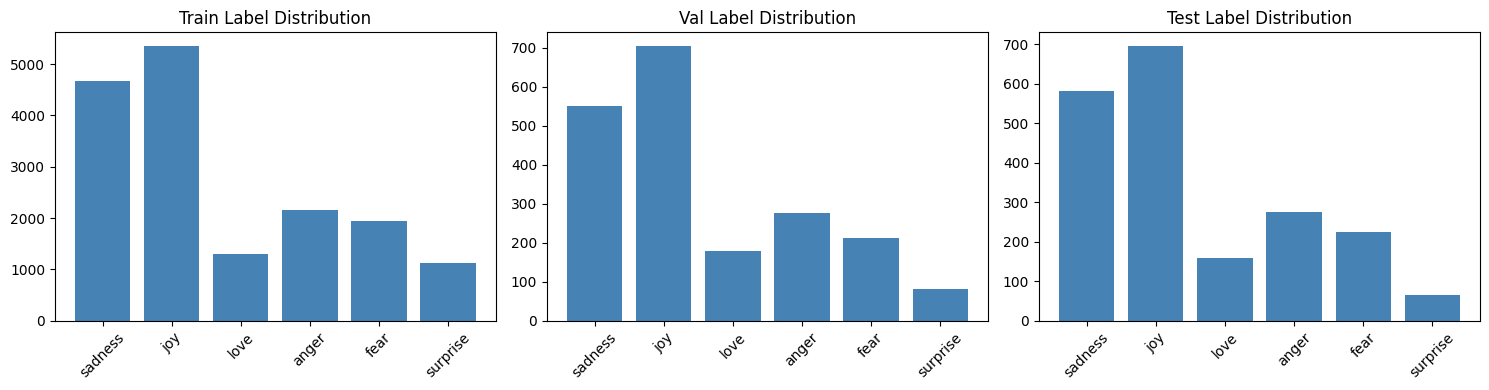

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, [("Train", df_train), ("Val", df_val), ("Test", df_test)]):
    counts = df["label"].value_counts().sort_index()
    ax.bar([LABEL_NAMES[i] for i in counts.index], counts.values, color="steelblue")
    ax.set_title(f"{name} Label Distribution")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 3. Tokenizer & Dataset

Sử dụng DistilBERT tokenizer (WordPiece) — không cần xây vocab thủ công như LSTM.

In [4]:
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

# Demo tokenization
sample = df_train["text"].iloc[0]
encoded = tokenizer(sample, max_length=MAX_LEN, padding="max_length", truncation=True)
print(f"Text: {sample}")
print(f"Tokens: {tokenizer.convert_ids_to_tokens(encoded['input_ids'][:20])}")
print(f"Input IDs (first 20): {encoded['input_ids'][:20]}")
print(f"Attention mask (first 20): {encoded['attention_mask'][:20]}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Text: i feel empty when the baby isnt there
Tokens: ['[CLS]', 'i', 'feel', 'empty', 'when', 'the', 'baby', 'isn', '##t', 'there', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Input IDs (first 20): [101, 1045, 2514, 4064, 2043, 1996, 3336, 3475, 2102, 2045, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Attention mask (first 20): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [5]:
class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts = df["text"].values
        self.labels = df["label"].values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_ds = EmotionDataset(df_train, tokenizer, MAX_LEN)
val_ds   = EmotionDataset(df_val,   tokenizer, MAX_LEN)
test_ds  = EmotionDataset(df_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

batch = next(iter(train_loader))
print(f"input_ids: {batch['input_ids'].shape}")
print(f"attention_mask: {batch['attention_mask'].shape}")
print(f"label: {batch['label'].shape}")

input_ids: torch.Size([32, 128])
attention_mask: torch.Size([32, 128])
label: torch.Size([32])


## 4. Model

Sử dụng `DistilBertForSequenceClassification` — DistilBERT pretrained + classification head.

DistilBERT có 6 transformer layers, ~66M parameters — nhẹ hơn BERT-base (110M) nhưng giữ 97% hiệu năng.

In [6]:
from transformers import DistilBertConfig

def create_model():
    """Create a fresh DistilBERT model for sequence classification."""
    config = DistilBertConfig.from_pretrained(MODEL_NAME)
    config.num_labels = NUM_CLASSES
    config.seq_classif_dropout = CLASSIFIER_DROPOUT  # 0.2 → 0.4
    model = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        config=config,
    ).to(DEVICE)
    return model

model = create_model()
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
print(model)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 66,958,086 / 66,958,086 (100.0%)
DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
  

## 5. Training Utilities

**Các kỹ thuật chống overfitting được áp dụng:**

| Kỹ thuật | Giá trị | Mục đích |
|----------|---------|----------|
| Label Smoothing | 0.1 | Tránh model quá tự tin vào 1 class → soft targets |
| Classifier Dropout | 0.4 (↑ từ 0.2) | Regularize classifier head mạnh hơn |
| Weight Decay | 0.02 (↑ từ 0.01) | L2 regularization, giữ weights nhỏ |
| Warmup + Cosine Decay | 10% warmup | Tránh cập nhật quá mạnh ở đầu, giảm LR mượt ở cuối |
| Early Stopping | patience=2 (↓ từ 3) | Dừng sớm hơn khi val loss bắt đầu tăng |
| Gradient Clipping | max_norm=1.0 | Ngăn gradient explosion |

In [7]:
# Sqrt class weights — nhe hon inverse frequency, tranh bias qua manh ve minority
# inverse freq: surprise weight = 9x joy -> MODEL CHI PREDICT SURPRISE
# sqrt inverse freq: surprise weight = 3x joy -> du de model chu y minority ma khong bias
import math

class_counts = df_train["label"].value_counts().sort_index().values
class_weights = 1.0 / np.sqrt(class_counts.astype(float))
class_weights = torch.tensor(class_weights / class_weights.sum() * NUM_CLASSES, dtype=torch.float)
print(f"Class weights (sqrt): { {LABEL_NAMES[i]: f'{w:.3f}' for i, w in enumerate(class_weights)} }")

def get_linear_warmup_cosine_scheduler(optimizer, num_warmup_steps, num_training_steps):
    """Linear warmup + cosine decay."""
    from torch.optim.lr_scheduler import LambdaLR
    import math as _math

    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + _math.cos(_math.pi * progress)))

    return LambdaLR(optimizer, lr_lambda)

def train_one_epoch(model, loader, criterion, optimizer, scheduler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item() * input_ids.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += input_ids.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = criterion(logits, labels)

        total_loss += loss.item() * input_ids.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += input_ids.size(0)
    return total_loss / total, correct / total

def get_predictions(model, loader):
    """Collect all predictions and labels from a DataLoader."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(batch["label"].numpy())
    return np.array(all_labels), np.array(all_preds)

def run_experiment(strategy_name, model, optimizer, epochs=EPOCHS, patience=EARLY_STOP_PATIENCE):
    """Train model with given optimizer and return results dict."""
    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE),
        label_smoothing=LABEL_SMOOTHING,
    )

    num_training_steps = len(train_loader) * epochs
    num_warmup_steps = int(num_training_steps * WARMUP_RATIO)
    scheduler = get_linear_warmup_cosine_scheduler(optimizer, num_warmup_steps, num_training_steps)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    no_improve = 0
    best_state = None

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"\n{'='*65}")
    print(f"  Strategy: {strategy_name}")
    print(f"  Trainable params: {trainable:,} / {total_params:,} ({100*trainable/total_params:.1f}%)")
    print(f"  Anti-overfitting: label_smoothing={LABEL_SMOOTHING}, dropout={CLASSIFIER_DROPOUT},")
    print(f"    weight_decay={WEIGHT_DECAY}, warmup={num_warmup_steps}/{num_training_steps} steps")
    print(f"{'='*65}")

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scheduler)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            marker = " *"
        else:
            no_improve += 1
            marker = ""

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}{marker}"
        )

        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

    train_time = time.time() - start_time

    model.load_state_dict(best_state)
    model.to(DEVICE)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    labels, preds = get_predictions(model, test_loader)

    report = classification_report(labels, preds, target_names=LABEL_NAMES, digits=4, output_dict=True)

    print(f"\n>>> Test Accuracy: {test_acc:.4f} | Macro F1: {report['macro avg']['f1-score']:.4f} | Time: {train_time:.1f}s")
    print(classification_report(labels, preds, target_names=LABEL_NAMES, digits=4))

    return {
        "name": strategy_name,
        "model": model,
        "history": history,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "train_time": train_time,
        "labels": labels,
        "preds": preds,
        "report": report,
        "best_val_loss": best_val_loss,
    }

results = {}

Class weights (sqrt): {'sadness': '0.674', 'joy': '0.630', 'love': '1.278', 'anger': '0.992', 'fear': '1.048', 'surprise': '1.378'}


## 6. Strategy 1 — Freeze Backbone (Đóng băng mạng xương sống)

Đóng băng toàn bộ DistilBERT backbone (embeddings + 6 transformer layers), chỉ huấn luyện classifier head.

- **Ưu điểm:** Nhanh, ít tham số cần học, tránh overfitting.
- **Nhược điểm:** Backbone không thích nghi được với domain cụ thể.

In [8]:
torch.manual_seed(SEED)
np.random.seed(SEED)

model_s1 = create_model()

# Freeze toàn bộ DistilBERT backbone → chỉ train classifier head
for param in model_s1.distilbert.parameters():
    param.requires_grad = False

optimizer_s1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_s1.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY,
)

results["freeze"] = run_experiment("Freeze Backbone", model_s1, optimizer_s1)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Strategy: Freeze Backbone
  Trainable params: 595,206 / 66,958,086 (0.9%)
  Anti-overfitting: label_smoothing=0.1, dropout=0.4,
    weight_decay=0.02, warmup=775/7755 steps
Epoch 01/15 | Train Loss: 1.8064 Acc: 0.2814 | Val Loss: 1.7661 Acc: 0.4630 *
Epoch 02/15 | Train Loss: 1.7524 Acc: 0.4231 | Val Loss: 1.7024 Acc: 0.4900 *
Epoch 03/15 | Train Loss: 1.6912 Acc: 0.4672 | Val Loss: 1.6443 Acc: 0.5000 *
Epoch 04/15 | Train Loss: 1.6453 Acc: 0.4792 | Val Loss: 1.6049 Acc: 0.5155 *
Epoch 05/15 | Train Loss: 1.6125 Acc: 0.4899 | Val Loss: 1.5817 Acc: 0.5230 *
Epoch 06/15 | Train Loss: 1.5888 Acc: 0.5016 | Val Loss: 1.5575 Acc: 0.5380 *
Epoch 07/15 | Train Loss: 1.5748 Acc: 0.5089 | Val Loss: 1.5446 Acc: 0.5395 *
Epoch 08/15 | Train Loss: 1.5611 Acc: 0.5118 | Val Loss: 1.5383 Acc: 0.5410 *
Epoch 09/15 | Train Loss: 1.5502 Acc: 0.5193 | Val Loss: 1.5286 Acc: 0.5455 *
Epoch 10/15 | Train Loss: 1.5474 Acc: 0.5176 | Val Loss: 1.5233 Acc: 0.5470 *
Epoch 11/15 | Train Loss: 1.5411 Acc: 0.5215

## 7. Strategy 2 — Full Fine-tune (Tinh chỉnh toàn bộ)

Tất cả tham số (backbone + classifier) đều được huấn luyện với cùng learning rate.

- **Ưu điểm:** Toàn bộ mô hình thích nghi với dữ liệu mới.
- **Nhược điểm:** Dễ overfitting, pretrained weights có thể bị phá hỏng (catastrophic forgetting).

In [9]:
torch.manual_seed(SEED)
np.random.seed(SEED)

model_s2 = create_model()

# Full fine-tune: tất cả params cùng learning rate
optimizer_s2 = torch.optim.AdamW(model_s2.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

results["full"] = run_experiment("Full Fine-tune", model_s2, optimizer_s2)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Strategy: Full Fine-tune
  Trainable params: 66,958,086 / 66,958,086 (100.0%)
  Anti-overfitting: label_smoothing=0.1, dropout=0.4,
    weight_decay=0.02, warmup=775/7755 steps
Epoch 01/15 | Train Loss: 1.4581 Acc: 0.5298 | Val Loss: 0.7330 Acc: 0.9025 *
Epoch 02/15 | Train Loss: 0.6702 Acc: 0.9183 | Val Loss: 0.6173 Acc: 0.9390 *
Epoch 03/15 | Train Loss: 0.6006 Acc: 0.9465 | Val Loss: 0.6223 Acc: 0.9365
Epoch 04/15 | Train Loss: 0.5744 Acc: 0.9584 | Val Loss: 0.6386 Acc: 0.9320
Epoch 05/15 | Train Loss: 0.5537 Acc: 0.9699 | Val Loss: 0.6449 Acc: 0.9355

Early stopping at epoch 5 (no improvement for 3 epochs)

>>> Test Accuracy: 0.9295 | Macro F1: 0.8956 | Time: 857.2s
              precision    recall  f1-score   support

     sadness     0.9654    0.9604    0.9629       581
         joy     0.9588    0.9381    0.9484       695
        love     0.8081    0.8742    0.8399       159
       anger     0.9149    0.9382    0.9264       275
        fear     0.9502    0.8527    0.8988    

## 8. Strategy 3 — Layer-wise Learning Rate (Tốc độ học theo từng tầng)

Mỗi nhóm tầng có learning rate riêng:
- **Embeddings:** LR thấp nhất (5e-6) — giữ tri thức ngôn ngữ tổng quát.
- **Transformer layers:** LR thấp (5e-6) — adapt nhẹ biểu diễn ngữ cảnh.
- **Classifier head:** LR cao (2e-5) — học nhanh task-specific mapping.

Đây là chiến lược cân bằng, tránh catastrophic forgetting trong khi vẫn adapt được backbone.

In [10]:
torch.manual_seed(SEED)
np.random.seed(SEED)

model_s3 = create_model()

# Layer-wise LR: backbone học chậm hơn, classifier head học nhanh hơn
optimizer_s3 = torch.optim.AdamW([
    {"params": model_s3.distilbert.embeddings.parameters(), "lr": BACKBONE_LR},    # 5e-6
    {"params": model_s3.distilbert.transformer.parameters(), "lr": BACKBONE_LR},   # 5e-6
    {"params": model_s3.pre_classifier.parameters(),         "lr": LR},             # 2e-5
    {"params": model_s3.classifier.parameters(),             "lr": LR},             # 2e-5
], weight_decay=WEIGHT_DECAY)

print(f"Backbone LR: {BACKBONE_LR}, Classifier LR: {LR} (ratio: {LR/BACKBONE_LR:.0f}x)")

results["layerwise"] = run_experiment("Layer-wise LR", model_s3, optimizer_s3)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Backbone LR: 2e-06, Classifier LR: 2e-05 (ratio: 10x)

  Strategy: Layer-wise LR
  Trainable params: 66,958,086 / 66,958,086 (100.0%)
  Anti-overfitting: label_smoothing=0.1, dropout=0.4,
    weight_decay=0.02, warmup=775/7755 steps
Epoch 01/15 | Train Loss: 1.7853 Acc: 0.3189 | Val Loss: 1.5769 Acc: 0.5420 *
Epoch 02/15 | Train Loss: 1.2369 Acc: 0.6855 | Val Loss: 0.9363 Acc: 0.8170 *
Epoch 03/15 | Train Loss: 0.8528 Acc: 0.8430 | Val Loss: 0.7695 Acc: 0.8750 *
Epoch 04/15 | Train Loss: 0.7374 Acc: 0.8903 | Val Loss: 0.7105 Acc: 0.8975 *
Epoch 05/15 | Train Loss: 0.6830 Acc: 0.9118 | Val Loss: 0.6762 Acc: 0.9120 *
Epoch 06/15 | Train Loss: 0.6545 Acc: 0.9230 | Val Loss: 0.6601 Acc: 0.9195 *
Epoch 07/15 | Train Loss: 0.6403 Acc: 0.9300 | Val Loss: 0.6523 Acc: 0.9215 *
Epoch 08/15 | Train Loss: 0.6241 Acc: 0.9355 | Val Loss: 0.6433 Acc: 0.9250 *
Epoch 09/15 | Train Loss: 0.6145 Acc: 0.9414 | Val Loss: 0.6401 Acc: 0.9255 *
Epoch 10/15 | Train Loss: 0.6107 Acc: 0.9416 | Val Loss: 0.6388 A

## 9. So sánh kết quả (Results Comparison)

  DistilBERT Fine-tuning Strategy Comparison
       Strategy Test Accuracy Macro F1 Weighted F1 Train Time (s) Best Val Loss
Freeze Backbone        0.5440   0.3854      0.5161          931.8        1.5185
 Full Fine-tune        0.9295   0.8956      0.9304          857.2        0.6173
  Layer-wise LR        0.9195   0.8805      0.9215         2575.7        0.6345



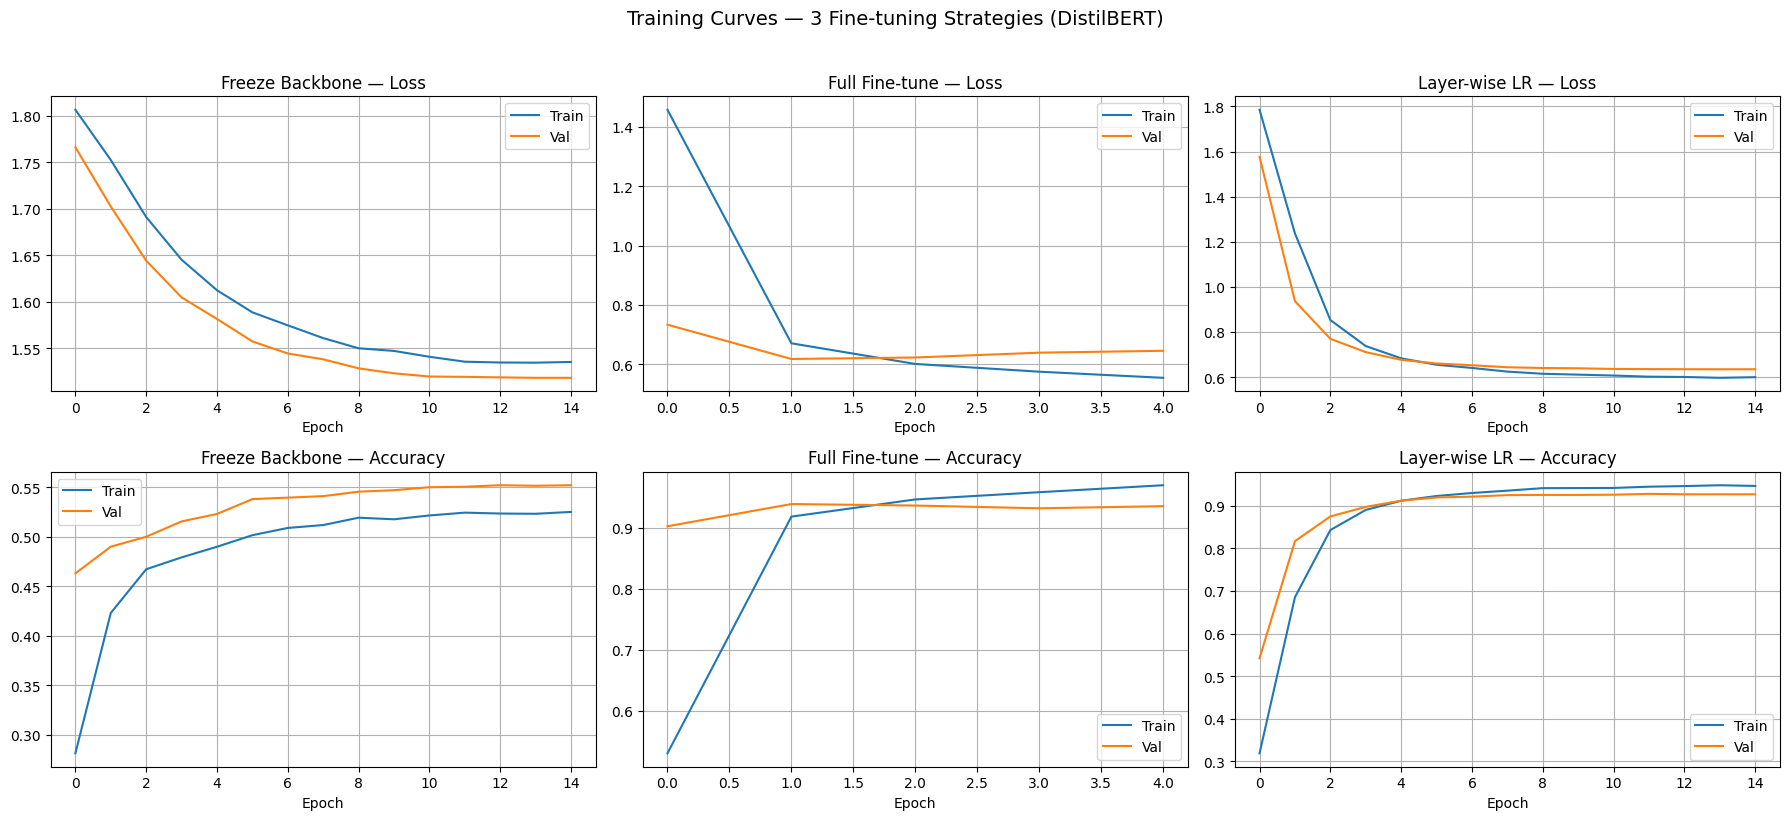

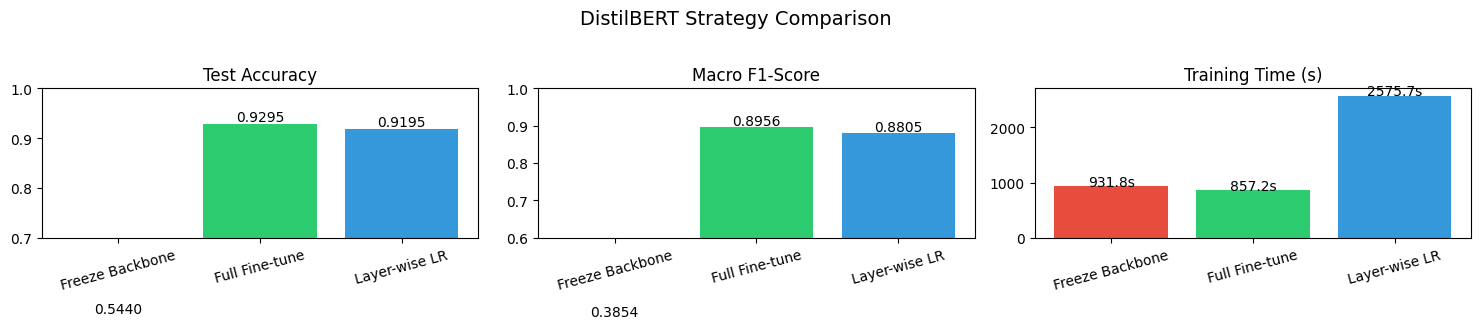

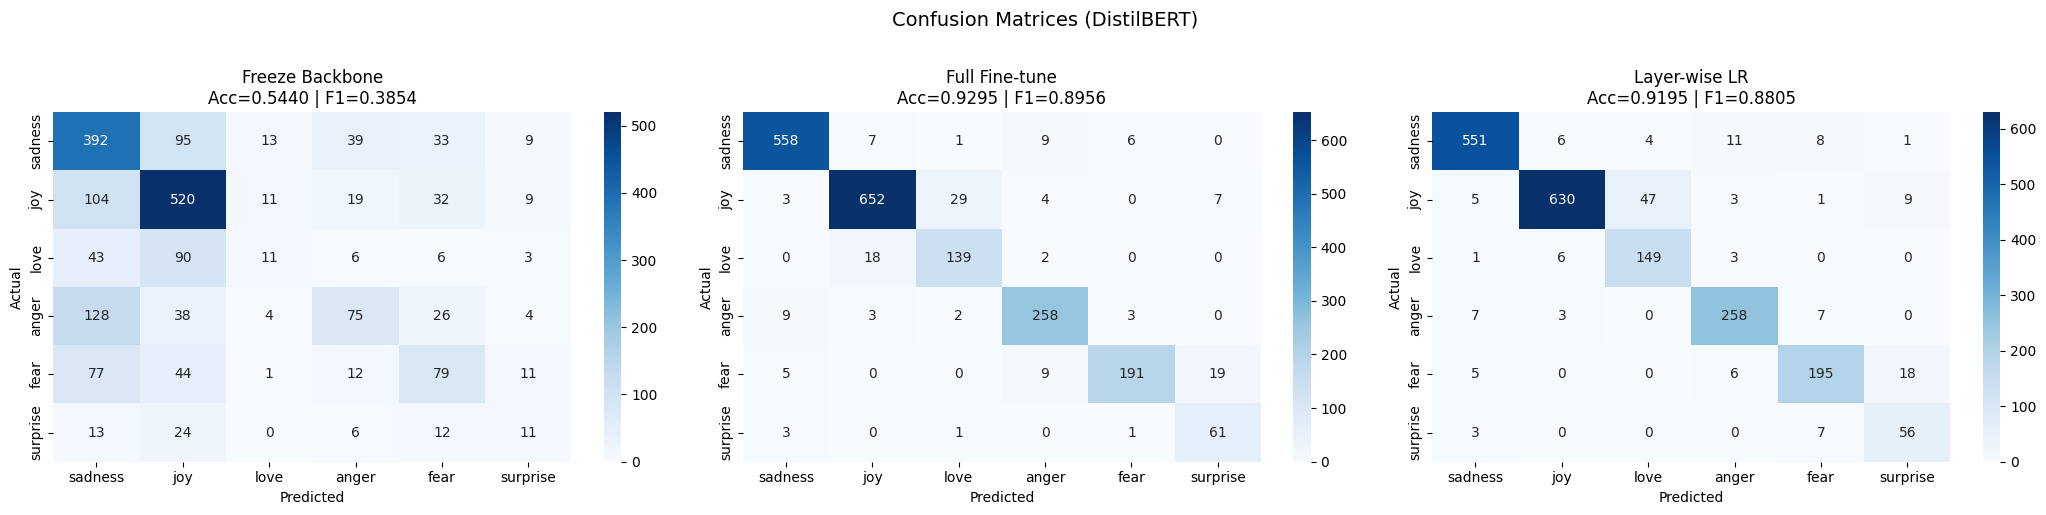


Best strategy: Full Fine-tune (Macro F1: 0.8956)
Saved best model to best_distilbert_model.pt


In [11]:
# === Summary Table ===
summary = pd.DataFrame([
    {
        "Strategy": r["name"],
        "Test Accuracy": f"{r['test_acc']:.4f}",
        "Macro F1": f"{r['macro_f1']:.4f}",
        "Weighted F1": f"{r['weighted_f1']:.4f}",
        "Train Time (s)": f"{r['train_time']:.1f}",
        "Best Val Loss": f"{r['best_val_loss']:.4f}",
    }
    for r in results.values()
])
print("=" * 85)
print("  DistilBERT Fine-tuning Strategy Comparison")
print("=" * 85)
print(summary.to_string(index=False))
print()

# === Training Curves ===
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i, (key, r) in enumerate(results.items()):
    axes[0, i].plot(r["history"]["train_loss"], label="Train")
    axes[0, i].plot(r["history"]["val_loss"], label="Val")
    axes[0, i].set_title(f'{r["name"]} — Loss')
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].legend()
    axes[0, i].grid(True)

    axes[1, i].plot(r["history"]["train_acc"], label="Train")
    axes[1, i].plot(r["history"]["val_acc"], label="Val")
    axes[1, i].set_title(f'{r["name"]} — Accuracy')
    axes[1, i].set_xlabel("Epoch")
    axes[1, i].legend()
    axes[1, i].grid(True)
plt.suptitle("Training Curves — 3 Fine-tuning Strategies (DistilBERT)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# === Bar Chart Comparison ===
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = [r["name"] for r in results.values()]
colors = ["#e74c3c", "#2ecc71", "#3498db"]

axes[0].bar(names, [r["test_acc"] for r in results.values()], color=colors)
axes[0].set_title("Test Accuracy")
axes[0].set_ylim(0.0, 1.0)
for j, r in enumerate(results.values()):
    axes[0].text(j, r["test_acc"] + 0.005, f"{r['test_acc']:.4f}", ha="center", fontsize=10)

axes[1].bar(names, [r["macro_f1"] for r in results.values()], color=colors)
axes[1].set_title("Macro F1-Score")
axes[1].set_ylim(0.0, 1.0)
for j, r in enumerate(results.values()):
    axes[1].text(j, r["macro_f1"] + 0.005, f"{r['macro_f1']:.4f}", ha="center", fontsize=10)

axes[2].bar(names, [r["train_time"] for r in results.values()], color=colors)
axes[2].set_title("Training Time (s)")
for j, r in enumerate(results.values()):
    axes[2].text(j, r["train_time"] + 0.5, f"{r['train_time']:.1f}s", ha="center", fontsize=10)

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("DistilBERT Strategy Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# === Confusion Matrices ===
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for ax, (key, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["labels"], r["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_title(f'{r["name"]}\nAcc={r["test_acc"]:.4f} | F1={r["macro_f1"]:.4f}')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices (DistilBERT)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# === Save best model ===
best_key = max(results, key=lambda k: results[k]["macro_f1"])
best_result = results[best_key]
torch.save(best_result["model"].state_dict(), "best_distilbert_model.pt")
print(f"\nBest strategy: {best_result['name']} (Macro F1: {best_result['macro_f1']:.4f})")
print("Saved best model to best_distilbert_model.pt")

## 10. Inference (Demo)

In [12]:
def predict_emotion(text, model, tokenizer, max_len=MAX_LEN):
    model.eval()
    encoded = tokenizer(
        text, max_length=max_len, padding="max_length",
        truncation=True, return_tensors="pt",
    )
    input_ids = encoded["input_ids"].to(DEVICE)
    attention_mask = encoded["attention_mask"].to(DEVICE)

    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred = probs.argmax()
    return LABEL_NAMES[pred], {LABEL_NAMES[i]: f"{p:.4f}" for i, p in enumerate(probs)}

# Use the best strategy model
best_model = best_result["model"]
print(f"Using best model: {best_result['name']} (Macro F1: {best_result['macro_f1']:.4f})\n")

test_sentences = [
    "i feel so happy and grateful today",
    "i am really angry about what happened",
    "this is so scary i cant sleep",
    "i feel so sad and lonely",
    "I really love her",
    "wow i did not expect that at all",
]

for s in test_sentences:
    label, probs = predict_emotion(s, best_model, tokenizer)
    print(f"\"{s}\"")
    print(f"  => {label} | {probs}\n")

Using best model: Full Fine-tune (Macro F1: 0.8956)

"i feel so happy and grateful today"
  => joy | {'sadness': '0.0134', 'joy': '0.8889', 'love': '0.0331', 'anger': '0.0173', 'fear': '0.0176', 'surprise': '0.0296'}

"i am really angry about what happened"
  => anger | {'sadness': '0.0095', 'joy': '0.0080', 'love': '0.0145', 'anger': '0.9385', 'fear': '0.0127', 'surprise': '0.0169'}

"this is so scary i cant sleep"
  => fear | {'sadness': '0.0333', 'joy': '0.0359', 'love': '0.0275', 'anger': '0.1059', 'fear': '0.7322', 'surprise': '0.0654'}

"i feel so sad and lonely"
  => sadness | {'sadness': '0.8947', 'joy': '0.0125', 'love': '0.0314', 'anger': '0.0185', 'fear': '0.0164', 'surprise': '0.0265'}

"I really love her"
  => love | {'sadness': '0.0342', 'joy': '0.1417', 'love': '0.7185', 'anger': '0.0474', 'fear': '0.0239', 'surprise': '0.0344'}

"wow i did not expect that at all"
  => surprise | {'sadness': '0.0247', 'joy': '0.1229', 'love': '0.0295', 'anger': '0.0682', 'fear': '0.0546'